In [ ]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

SOC_NPZ = '/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data/sort_of_clevr-seed1-train36000-test1000-q10-t-1'
SQOOP_NPZ = '/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data/sqoop-rhs1/val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
OUT_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})

In [2]:
import textwrap

from IPython.display import Image, display
from src.datasets.soc.translate import translate_question, translate_answer

soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
chosen = [
    ('Non-relational', 'nonrel_questions', 'nonrel_answers', 0),
    ('Binary', 'binary_questions', 'binary_answers', 0),
    ('Ternary', 'ternary_questions', 'ternary_answers', 1),
]

q_left = 0.26
q_wrap = 30
a_left = 0.85
fontsize = 8.0

blocks = []
for label, qkey, akey, j in chosen:
    q = soc[qkey][scene][j]
    a = soc[akey][scene][j]
    blocks.append((label, textwrap.wrap(translate_question(q), q_wrap),
                   translate_answer(a, q)))

n_lines = sum(len(lines) for _, lines, _ in blocks)
line_height = 1.0 / (n_lines + 0.45 * len(blocks) + 1.5)

fig = plt.figure(figsize=(6.0, 1.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3.05], wspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax1.imshow(soc['images'][scene][..., ::-1], interpolation='nearest')
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

ax2 = fig.add_subplot(gs[1])
ax2.axis('off')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

y = 1.0
ax2.text(0.0, y, 'family', weight='bold', va='top', fontsize=7.0)
ax2.text(q_left, y, 'question', weight='bold', va='top', fontsize=7.0)
ax2.text(a_left, y, 'answer', weight='bold', va='top', fontsize=7.0)
y -= line_height
ax2.plot([0, 1], [y + 0.2 * line_height, y + 0.2 * line_height],
         color='#999999', linewidth=0.5)
y -= 0.5 * line_height

for label, lines, answer in blocks:
    ax2.text(0.0, y, label, va='top', fontsize=fontsize)
    ax2.text(a_left, y, answer, va='top', fontsize=fontsize, style='italic')
    for line in lines:
        ax2.text(q_left, y, line, va='top', fontsize=fontsize)
        y -= line_height
    y -= 0.45 * line_height

fig.savefig(OUT_DIR / 'soc_example.png')
display(Image(OUT_DIR / 'soc_example.png'))

FileNotFoundError: [Errno 2] No such file or directory: '/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data/sort_of_clevr-seed1-train36000-test1000-img75-obj5-q10-t-1/test.npz'

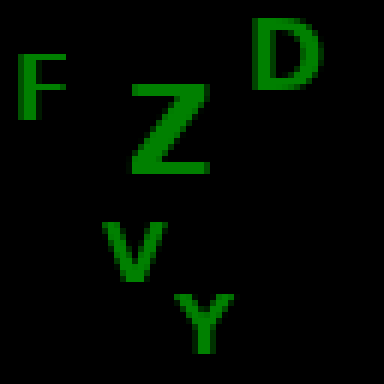

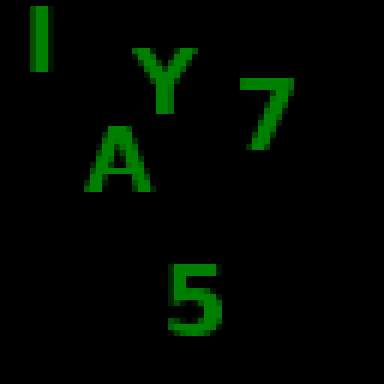

In [ ]:
d = np.load(SQOOP_NPZ, allow_pickle=False)

scale = 6

for i in range(2):
    img = np.repeat(np.repeat(d['images'][i], scale, axis=0), scale, axis=1)
    path = OUT_DIR / f'sqoop_example_{i}.png'
    plt.imsave(path, img)
    display(Image(path))

### results helpers + placeholder data

In [ ]:
from IPython.display import Image, display

rng = np.random.default_rng(0)
N_SEEDS = 5

T_CANON = 6          # canonical number of internal steps (Table 5.2)
M_CANON = 4          # canonical number of modules
D_CANON = 6          # canonical phase dimension

C_OVERALL = '#1f4e79'   # dark blue
C_TERNARY = '#c0504d'   # brick red
C_BINARY  = '#7f9c3e'   # olive
C_NONREL  = '#8c8c8c'   # grey
C_CANON   = '#999999'   # canonical-setting marker line


def _seeded(mean, sd=1.0, n=N_SEEDS):
    """Fake per-seed observations around a mean (placeholder only)."""
    return np.clip(mean + sd * rng.standard_normal(n), 0, 100)


def _curve(xs, f, sd=1.0):
    return {x: _seeded(f(x), sd) for x in xs}


# --- T ablations ------------------------------------------------------------
T_TEST  = [0, 1, 2, 4, 6, 8, 12, 16]
T_TRAIN = [0, 1, 2, 4, 6, 8, 12]

# accuracies are deltas above the prior-optimal floor (as in Table 5.2)
_sat = lambda x, a, k: a * (1 - np.exp(-x / k))
RES = {}
RES['t_test'] = {   # trained at T_CANON, evaluated with T_test steps
    'overall': _curve(T_TEST, lambda t: 40 * np.exp(-((t - T_CANON) / 5.0) ** 2) + 2, sd=1.2),
    'nonrel':  _curve(T_TEST, lambda t: 50 * np.exp(-((t - T_CANON) / 7.0) ** 2) + 4, sd=0.9),
    'binary':  _curve(T_TEST, lambda t: 38 * np.exp(-((t - T_CANON) / 5.0) ** 2) + 2, sd=1.3),
    'ternary': _curve(T_TEST, lambda t: 30 * np.exp(-((t - T_CANON) / 4.0) ** 2) + 1, sd=1.6),
}
RES['t_train'] = {  # trained and evaluated with the same T
    'overall': _curve(T_TRAIN, lambda t: _sat(t, 42, 3.0) + 1, sd=1.2),
    'nonrel':  _curve(T_TRAIN, lambda t: _sat(t, 52, 1.2) + 2, sd=0.9),
    'binary':  _curve(T_TRAIN, lambda t: _sat(t, 40, 3.0) + 1, sd=1.3),
    'ternary': _curve(T_TRAIN, lambda t: _sat(t, 32, 4.0) + 0.5, sd=1.6),
}

# --- combined train/test grid --------------------------------------------------
GRID_TRAIN = [1, 2, 4, 6, 8, 12]
GRID_TEST  = [1, 2, 4, 6, 8, 12, 16]
RES['t_grid'] = np.zeros((len(GRID_TRAIN), len(GRID_TEST), N_SEEDS))
for i, tr in enumerate(GRID_TRAIN):
    for j, te in enumerate(GRID_TEST):
        peak = _sat(tr, 42, 3.0)
        width = 2.0 + 0.6 * tr
        RES['t_grid'][i, j] = _seeded(peak * np.exp(-((te - tr) / width) ** 2) + 2, sd=1.2)

# --- module count / phase dimension -------------------------------------------
M_VALUES = [1, 2, 4, 6, 8, 12]
RES['n_modules'] = {
    'overall': _curve(M_VALUES, lambda m: 42 - 3.0 * abs(np.log2(m / M_CANON)) ** 1.3, sd=1.2),
    'nonrel':  _curve(M_VALUES, lambda m: 53 - 1.0 * abs(np.log2(m / M_CANON)) ** 1.3, sd=0.9),
    'binary':  _curve(M_VALUES, lambda m: 40 - 3.0 * abs(np.log2(m / M_CANON)) ** 1.3, sd=1.3),
    'ternary': _curve(M_VALUES, lambda m: 32 - 4.0 * abs(np.log2(m / M_CANON)) ** 1.3, sd=1.6),
}
D_VALUES = [2, 3, 4, 6, 8, 12]
RES['phase_dim'] = {
    'overall': _curve(D_VALUES, lambda d: _sat(d, 44, 2.5), sd=1.2),
    'nonrel':  _curve(D_VALUES, lambda d: _sat(d, 54, 1.0), sd=0.9),
    'binary':  _curve(D_VALUES, lambda d: _sat(d, 42, 2.5), sd=1.3),
    'ternary': _curve(D_VALUES, lambda d: _sat(d, 34, 3.5) - 1, sd=1.6),
}

# --- SQOOP (Table 5.3) ---------------------------------------------------------
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
SQOOP_MODELS = ['Q-Only', 'CNN+MLP', 'Conv+LSTM', 'RelNet', 'FiLM',
                'Transformer', 'Workspace', 'SyncNet']
# placeholder "difficulty" per model: (held-out asymptote, curvature)
_sq = {'Q-Only': (0.50, 0.0), 'CNN+MLP': (0.72, 0.20), 'Conv+LSTM': (0.80, 0.25),
       'RelNet': (0.90, 0.30), 'FiLM': (0.92, 0.32), 'Transformer': (0.88, 0.30),
       'Workspace': (0.93, 0.35), 'SyncNet': (0.96, 0.45)}
RES['sqoop'] = {}
for name, (top, k) in _sq.items():
    val = {v: np.clip(0.98 - 0.01 * rng.random(N_SEEDS), 0, 1) if name != 'Q-Only'
           else 0.50 + 0.005 * rng.standard_normal(N_SEEDS) for v in PAIR_VARIETY}
    held = {v: np.clip(0.5 + (top - 0.5) * (1 - np.exp(-k * v)) + 0.015 * rng.standard_normal(N_SEEDS), 0, 1)
            for v in PAIR_VARIETY}
    held[35] = val[35] - 0.005  # in-distribution control
    RES['sqoop'][name] = {'validation': val, 'held-out': held}


# Series drawn on every Sort-of-CLEVR ablation plot: (label, key, colour, marker)
SOC_SERIES = [
    ('Overall',        'overall', C_OVERALL, 'o'),
    ('Non-relational', 'nonrel',  C_NONREL,  '^'),
    ('Binary',         'binary',  C_BINARY,  'D'),
    ('Ternary',        'ternary', C_TERNARY, 's'),
]


def soc_series(res):
    return [(label, res[key], colour, marker) for label, key, colour, marker in SOC_SERIES]


# --- helpers ----------------------------------------------------------------------
def mean_sd(d, keys):
    m = np.array([np.mean(d[k]) for k in keys])
    s = np.array([np.std(d[k], ddof=1) for k in keys])
    return m, s


def ablation_plot(ax, xs, series, canon=None, xlabel='', ylabel='Accuracy above floor (%)',
                  log_x=False, legend=True):
    """One-panel line plot with mean ± s.d. bands; `series` = [(label, dict, colour, marker)]."""
    for label, d, colour, marker in series:
        m, s = mean_sd(d, xs)
        lw = 1.6 if label == 'Overall' else 1.0
        ax.plot(xs, m, color=colour, marker=marker, markersize=3.2, linewidth=lw,
                label=label, zorder=3)
        ax.fill_between(xs, m - s, m + s, color=colour, alpha=0.18, linewidth=0, zorder=2)
    if canon is not None:
        ax.axvline(canon, color=C_CANON, linestyle='--', linewidth=0.7, zorder=1)
    if log_x:
        ax.set_xscale('log', base=2)
        ax.set_xticks(xs)
        ax.set_xticklabels([str(x) for x in xs])
        ax.minorticks_off()
    else:
        ax.set_xticks(xs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis='y', color='#e5e5e5', linewidth=0.5)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    if legend:
        ax.legend(frameon=False, fontsize=7, handlelength=1.6, labelspacing=0.3)


def save_show(fig, name):
    path = OUT_DIR / f'{name}.png'
    fig.savefig(path)
    plt.close(fig)
    display(Image(path))

### test-time T ablation

In [ ]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
ablation_plot(ax, T_TEST,
              soc_series(RES['t_test']),
              canon=T_CANON, xlabel=r'Test-time steps $T_{\mathrm{test}}$')
ax.text(T_CANON, ax.get_ylim()[1], r'$T_{\mathrm{train}}$', ha='center', va='bottom',
        fontsize=7, color='#666666')
save_show(fig, 'soc_ablation_t_test')

### train-time T ablation

In [ ]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
ablation_plot(ax, T_TRAIN,
              soc_series(RES['t_train']),
              canon=T_CANON, xlabel=r'Internal steps $T$ (train $=$ test)')
save_show(fig, 'soc_ablation_t_train')

### combined train/test T surface

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

Z = RES['t_grid'].mean(axis=-1)                     # (train, test)
TR, TE = np.meshgrid(GRID_TRAIN, GRID_TEST, indexing='ij')

fig = plt.figure(figsize=(4.8, 3.6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(np.log2(TR), np.log2(TE), Z, cmap='viridis',
                       linewidth=0.3, edgecolor='#ffffff', alpha=0.95, antialiased=True)
# diagonal (train = test) drawn on top of the surface
diag = [Z[i, GRID_TEST.index(t)] for i, t in enumerate(GRID_TRAIN)]
ax.plot(np.log2(GRID_TRAIN), np.log2(GRID_TRAIN), diag, color=C_TERNARY,
        linewidth=1.4, marker='o', markersize=3, zorder=10, label=r'$T_{\mathrm{test}} = T_{\mathrm{train}}$')

ax.set_xticks(np.log2(GRID_TRAIN)); ax.set_xticklabels(GRID_TRAIN)
ax.set_yticks(np.log2(GRID_TEST));  ax.set_yticklabels([t if t in (1, 2, 4, 8, 16) else '' for t in GRID_TEST])
ax.set_xlabel(r'$T_{\mathrm{train}}$', labelpad=2)
ax.set_ylabel(r'$T_{\mathrm{test}}$', labelpad=2)
fig.text(0.13, 0.55, 'Accuracy above floor (%)', rotation=90, va='center', ha='center')
ax.tick_params(pad=1)
ax.view_init(elev=25, azim=-128)
ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_edgecolor('#dddddd')
    axis._axinfo['grid']['color'] = '#e5e5e5'
    axis._axinfo['grid']['linewidth'] = 0.5
ax.legend(frameon=False, fontsize=7.5, loc='upper left', bbox_to_anchor=(0.0, 0.98))
ax.set_box_aspect(None, zoom=0.92)
save_show(fig, 'soc_ablation_t_surface')

# Print-friendly alternative: the same grid as a heatmap (often easier to read).
fig, ax = plt.subplots(figsize=(3.6, 2.8))
im = ax.imshow(Z, cmap='viridis', origin='lower', aspect='auto')
ax.set_xticks(range(len(GRID_TEST)));  ax.set_xticklabels(GRID_TEST)
ax.set_yticks(range(len(GRID_TRAIN))); ax.set_yticklabels(GRID_TRAIN)
ax.set_xlabel(r'$T_{\mathrm{test}}$'); ax.set_ylabel(r'$T_{\mathrm{train}}$')
for i in range(len(GRID_TRAIN)):
    for j in range(len(GRID_TEST)):
        ax.text(j, i, f'{Z[i, j]:.0f}', ha='center', va='center', fontsize=6.5,
                color='white' if Z[i, j] < Z.max() * 0.6 else 'black')
        if GRID_TRAIN[i] == GRID_TEST[j]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor=C_TERNARY, linewidth=1.2))
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
cb.set_label('Overall accuracy above floor (%)', fontsize=7.5)
cb.ax.tick_params(labelsize=7)
save_show(fig, 'soc_ablation_t_heatmap')

### number-of-modules ablation

In [ ]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
ablation_plot(ax, M_VALUES,
              soc_series(RES['n_modules']),
              canon=M_CANON, xlabel=r'Number of modules $M$', log_x=True)
save_show(fig, 'soc_ablation_n_modules')

### phase-dimension ablation

In [ ]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
ablation_plot(ax, D_VALUES,
              soc_series(RES['phase_dim']),
              canon=D_CANON, xlabel=r'Phase dimension $d$', log_x=True)
save_show(fig, 'soc_ablation_phase_dim')

### SQOOP grouped bar chart (Table 5.3)

In [ ]:
MODEL_COLOURS = {
    'Q-Only': '#bdbdbd', 'CNN+MLP': '#9ecae1', 'Conv+LSTM': '#6baed6',
    'RelNet': '#4292c6', 'FiLM': '#2171b5', 'Transformer': '#08519c',
    'Workspace': '#7f9c3e', 'SyncNet': '#c0504d',
}

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
n_models = len(SQOOP_MODELS)
width = 0.8 / n_models
x = np.arange(len(PAIR_VARIETY))
for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        m, s = mean_sd(RES['sqoop'][name][split], PAIR_VARIETY)
        ax.bar(x + (k - (n_models - 1) / 2) * width, 100 * m, width,
               yerr=100 * s, error_kw=dict(elinewidth=0.5, capsize=0),
               color=MODEL_COLOURS[name], label=name, linewidth=0)
    ax.axhline(50, color='#666666', linestyle=':', linewidth=0.7)
    ax.set_xticks(x); ax.set_xticklabels(PAIR_VARIETY)
    ax.set_xlabel('Pair variety')
    ax.set_title(split, fontsize=8.5)
    ax.set_ylim(40, 101)
    ax.grid(True, axis='y', color='#e5e5e5', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[0].set_ylabel('Accuracy (%)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=7, ncol=4, loc='lower center',
           bbox_to_anchor=(0.5, -0.22), handlelength=1.0, columnspacing=1.2)
fig.subplots_adjust(wspace=0.08)
save_show(fig, 'sqoop_results_bars')

### SQOOP alternative — held-out accuracy vs pair variety per model

In [ ]:
fig, ax = plt.subplots(figsize=(3.6, 2.6))
for name in SQOOP_MODELS:
    m, s = mean_sd(RES['sqoop'][name]['held-out'], PAIR_VARIETY)
    lw = 1.6 if name == 'SyncNet' else 1.0
    ax.plot(PAIR_VARIETY, 100 * m, color=MODEL_COLOURS[name], marker='o',
            markersize=3, linewidth=lw, label=name, zorder=3)
    ax.fill_between(PAIR_VARIETY, 100 * (m - s), 100 * (m + s),
                    color=MODEL_COLOURS[name], alpha=0.15, linewidth=0, zorder=2)
ax.axhline(50, color='#666666', linestyle=':', linewidth=0.7, zorder=1)
ax.axvline(35, color=C_CANON, linestyle='--', linewidth=0.7, zorder=1)
ax.text(35, 101, 'in-dist.', ha='center', va='bottom', fontsize=6.5, color='#666666')
ax.set_xscale('log'); ax.set_xticks(PAIR_VARIETY); ax.set_xticklabels(PAIR_VARIETY)
ax.minorticks_off()
ax.set_xlabel('Pair variety'); ax.set_ylabel('Held-out accuracy (%)')
ax.set_ylim(40, 101)
ax.grid(True, axis='y', color='#e5e5e5', linewidth=0.5)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, fontsize=6.5, ncol=2, loc='lower right',
          handlelength=1.4, columnspacing=0.8)
save_show(fig, 'sqoop_results_lines')